In [ ]:
# The 'Six in Six' Bitcoin trading applet
# detects candles which yeild 6% gain in 6 Days

In [47]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix



In [48]:
# 1. Load the dataset WITH 'trigger' column added
# Clean the dataset
df = pd.read_csv('df_full_features_added.csv')
#print(df.head())
# cols are:
# date
# trigger	
# close	
# volume	
# ret_1d	
# ret_3d	
# ret_5d	
# vol_5d	
# rsi_14	
# atr_14


# Standardize column names
df.columns = [c.strip().lower() for c in df.columns] # Cleans column names: removes spaces, makes everything lowercase

# Convert and sort by time: ensures proper time ordering, prevents future data leaking into the past
df['date'] = pd.to_datetime(df["date"], errors="coerce")
df = df.sort_values("date").reset_index(drop=True)

# Drop unused column, we needed this to label the 'trigger' column but don't need now
if "days_to_6_pct" in df.columns:
    df = df.drop(columns=["days_to_6_pct"])

# Drop rows where 'trigger', y-hat is NaN
df = df.dropna(subset=["trigger"])

# Make sure that classification model sees 0/1 (not floats or NaN) ensure 'trigger' is int
df["trigger"] = df["trigger"].astype(int)

print("Dataset shape after cleaning:", df.shape)
print("Positive rate (trigger=1):", round(df["trigger"].mean()*100, 2), "%")

# Peek at the first & last few rows
display(df.head())
display(df.tail())


Dataset shape after cleaning: (2827, 10)
Positive rate (trigger=1): 38.2 %


,date,trigger,close,volume,ret_1d,ret_3d,ret_5d,vol_5d,rsi_14,atr_14
0,2018-01-15,0,13539.93,14652.09471,0.004819,-0.014562,-0.091712,0.063878,50.775896,1860.680000
1,2018-01-16,1,10900.00,63401.16918,-0.194974,-0.232935,-0.176661,0.096889,33.799160,1998.141429
2,2018-01-17,1,10988.79,72331.79665,0.008146,-0.184505,-0.200234,0.092179,32.903015,2104.247857
3,2018-01-18,1,10961.97,48464.43494,-0.002441,-0.190397,-0.228574,0.086067,32.000018,2110.071429
4,2018-01-19,1,11474.98,34129.37542,0.046799,0.052750,-0.148424,0.095539,22.557335,2028.554286


,date,trigger,close,volume,ret_1d,ret_3d,ret_5d,vol_5d,rsi_14,atr_14
2822,2025-10-07,0,125046.94,535.44520,0.011830,0.024211,0.054429,0.005552,76.978878,2340.394286
2823,2025-10-08,0,121832.92,790.37194,-0.025703,-0.003366,0.013400,0.016774,66.340718,2402.794286
2824,2025-10-09,0,122700.80,528.48578,0.007124,-0.007154,0.004995,0.015550,80.265668,2162.557143
2825,2025-10-10,0,121786.26,357.09667,-0.007453,-0.026076,-0.003748,0.016008,76.502364,2121.494286
2826,2025-10-11,0,112143.65,4004.34367,-0.079177,-0.079529,-0.092578,0.036851,53.852949,2799.097857


In [49]:
# Build a corr table to possibly remove redundant predictors
corr = df.drop(columns=["date"]).corr()

print(corr)

          trigger     close    volume    ret_1d    ret_3d    ret_5d    vol_5d  \
trigger  1.000000 -0.107953  0.053294 -0.006071  0.013772  0.006030  0.173782   
close   -0.107953  1.000000 -0.230397  0.018224  0.034135  0.044737 -0.175964   
volume   0.053294 -0.230397  1.000000  0.004826  0.009150  0.014532  0.205939   
ret_1d  -0.006071  0.018224  0.004826  1.000000  0.577773  0.450832  0.008649   
ret_3d   0.013772  0.034135  0.009150  0.577773  1.000000  0.779538 -0.033958   
ret_5d   0.006030  0.044737  0.014532  0.450832  0.779538  1.000000 -0.077254   
vol_5d   0.173782 -0.175964  0.205939  0.008649 -0.033958 -0.077254  1.000000   
rsi_14   0.029284  0.099851  0.012138  0.267179  0.460038  0.588421 -0.106535   
atr_14   0.015065  0.760831 -0.105880 -0.010507 -0.021888 -0.029348  0.154012   

           rsi_14    atr_14  
trigger  0.029284  0.015065  
close    0.099851  0.760831  
volume   0.012138 -0.105880  
ret_1d   0.267179 -0.010507  
ret_3d   0.460038 -0.021888  
ret_5d   

In [50]:
# keep relevant features for X and trigger as y
features = [
    "vol_5d",     # volatility regime (strongest signal)
    "volume",     # market activity / liquidity
    "ret_1d",     # short-term momentum
    "ret_5d",     # medium-term momentum
    "rsi_14"      # nonlinear momentum indicator
]

X = df[features]
y = df["trigger"]


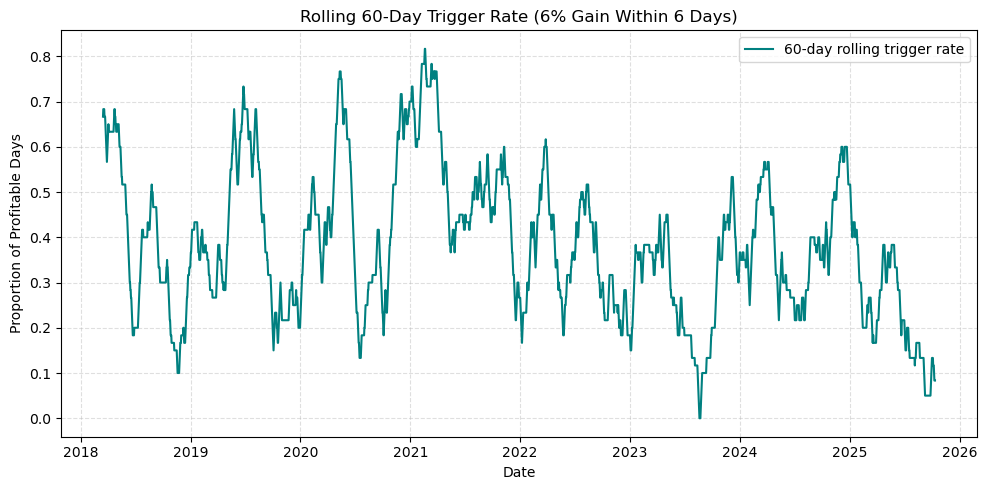

In [51]:
# Graphing the trigger rate over time

# Compute rolling trigger rate (e.g., 60-day window)
window = 60  # adjust for smoother / more granular view
trigger_rate = df["trigger"].shift(1).rolling(window).mean()

plt.figure(figsize=(10, 5))
plt.plot(df["date"], trigger_rate, label=f"{window}-day rolling trigger rate", color="teal")
plt.title(f"Rolling {window}-Day Trigger Rate (6% Gain Within 6 Days)")
plt.xlabel("Date")
plt.ylabel("Proportion of Profitable Days")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


In [52]:
# split the data train=.8, test=.2 
cut = int(len(df) * 0.8)

# Better for time series
X_train = X.iloc[:cut]
X_test  = X.iloc[cut:]

y_train = y.iloc[:cut]
y_test  = y.iloc[cut:]


print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

print("Train positive rate:", y_train.mean())
print("Test positive rate:", y_test.mean())

(2261, 5)
(566, 5)
(2261,)
(566,)
Train positive rate: 0.40645731977001326
Test positive rate: 0.284452296819788


In [53]:
# Define the X and Y columns and train Random Forest
# Thus far model1 is performing best
model1 = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=5, class_weight="balanced", random_state=42, n_jobs=-1)

#model2 = RandomForestClassifier(n_estimators=500, max_depth=8, min_samples_leaf=40, class_weight="balanced", random_state=42, n_jobs=-1)

#model3 = RandomForestClassifier(n_estimators=100, max_depth=3, min_samples_leaf=10)

model1.fit(X_train, y_train)
rf_train_accuracy = model1.score(X_train, y_train)
rf_test_accuracy = model1.score(X_test, y_test) 
print(rf_train_accuracy)
print(rf_test_accuracy)

0.7213622291021672
0.6713780918727915


In [54]:
# My model is not separating. check probability of X-Test
probs = model1.predict_proba(X_test)[:, 1]
print(probs)

[0.46891255 0.38647512 0.4226287  0.43072906 0.37044978 0.28216212
 0.39603059 0.39357956 0.4263469  0.42036862 0.41314783 0.40852692
 0.46387655 0.38279004 0.41549583 0.43050861 0.39764364 0.3915954
 0.47155155 0.46479947 0.48095548 0.48119189 0.46494933 0.47292172
 0.41141197 0.4570107  0.42502172 0.4015626  0.42205895 0.37081717
 0.46714754 0.3855928  0.3819827  0.38708749 0.37668173 0.38732165
 0.47382023 0.49504619 0.45580304 0.4569819  0.49387118 0.38319227
 0.38521836 0.38759106 0.37713564 0.39910289 0.48596282 0.30731636
 0.281417   0.41197048 0.44088779 0.4809588  0.48268269 0.46940446
 0.3131836  0.36627063 0.50992539 0.5136141  0.46825608 0.43213185
 0.50135159 0.44078858 0.36409154 0.50043932 0.43975196 0.36868566
 0.38726846 0.36102294 0.22153737 0.34271469 0.39610621 0.38751794
 0.39280857 0.48035453 0.37350849 0.21202818 0.23376466 0.34729322
 0.44128639 0.38098139 0.44136984 0.39219559 0.26612639 0.21180977
 0.37109687 0.48969994 0.45345715 0.46149246 0.49797804 0.36480

In [55]:
# Step 1: check threshold sensitivity
for t in [0.35, 0.4, 0.45, 0.5, 0.55]:
    y_pred = (probs > t).astype(int)
    print(t)
    print(classification_report(y_test, y_pred))

0.35
              precision    recall  f1-score   support

           0       0.76      0.26      0.39       405
           1       0.30      0.80      0.43       161

    accuracy                           0.41       566
   macro avg       0.53      0.53      0.41       566
weighted avg       0.63      0.41      0.40       566

0.4
              precision    recall  f1-score   support

           0       0.75      0.49      0.59       405
           1       0.32      0.60      0.41       161

    accuracy                           0.52       566
   macro avg       0.53      0.54      0.50       566
weighted avg       0.63      0.52      0.54       566

0.45
              precision    recall  f1-score   support

           0       0.74      0.69      0.71       405
           1       0.34      0.40      0.37       161

    accuracy                           0.61       566
   macro avg       0.54      0.55      0.54       566
weighted avg       0.63      0.61      0.62       566

0.5
 

In [39]:
# apply the threshold between 0.33-0.37
threshold = 0.35  # try 0.33–0.37 here

y_pred = (probs > threshold).astype(int)


print(classification_report(y_test, y_pred))


# class 0 (no break-outs)

              precision    recall  f1-score   support

           0       0.76      0.26      0.39       405
           1       0.30      0.80      0.43       161

    accuracy                           0.41       566
   macro avg       0.53      0.53      0.41       566
weighted avg       0.63      0.41      0.40       566

